In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/cleaned_Beer_data.csv")
df.head()

,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,...,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",-0.481696,0.28848,0.515791,-0.337764,-0.544620,...,-0.171238,0.528815,-0.435553,0.893892,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",0.264397,0.28848,0.515791,-0.433834,0.419002,...,-0.449949,-0.194896,-0.267152,0.217253,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,-0.599501,0.28848,0.515791,-0.241694,-0.351895,...,-0.883498,0.430127,-0.603954,-0.334083,3.409814,3.667109,3.600796,3.631300,3.830239,377
3,Doppelsticke,Altbier,Uerige Obergärige Hausbrauerei GmbH / Zum Uerige,Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...,Notes:,0.774882,0.28848,0.515791,-0.337764,0.341912,...,0.324247,-0.030416,-0.098752,1.094378,4.148098,4.033967,4.150815,4.205163,4.005435,368
4,Sleigh'r Dark Doüble Alt Ale,Altbier,Ninkasi Brewing Company,Ninkasi Brewing Company Sleigh'r Dark Doüble A...,Notes:Called 'Dark Double Alt' on the label.Se...,0.264397,0.28848,0.515791,0.815081,0.187733,...,-0.852530,0.331439,0.069649,0.492921,3.625000,3.973958,3.734375,3.765625,3.817708,96


In [4]:
# Beer specification variables
specific_cols = ['ABV', 'Min IBU', 'Max IBU']

profile_features = [
    'Astringency', 'Body', 'Alcohol',
    'Bitter', 'Sweet', 'Sour', 'Salty',
    'Fruits', 'Hoppy', 'Spices', 'Malty'
]

# Main variables used to check clusterability
cluster_features = specific_cols + profile_features

X = df[cluster_features].copy()

X = X.select_dtypes(include=[np.number])
X.head()

,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
0,-0.481696,0.28848,0.515791,-0.337764,-0.544620,-0.464895,0.412438,0.458897,-0.004066,-0.477041,-0.171238,0.528815,-0.435553,0.893892
1,0.264397,0.28848,0.515791,-0.433834,0.419002,0.054477,-0.130468,-0.095428,-0.479264,-0.477041,-0.449949,-0.194896,-0.267152,0.217253
2,-0.599501,0.28848,0.515791,-0.241694,-0.351895,-0.638019,0.218543,-0.445528,-0.619028,-0.477041,-0.883498,0.430127,-0.603954,-0.334083
3,0.774882,0.28848,0.515791,-0.337764,0.341912,0.804681,0.412438,1.246621,-0.423358,-0.008068,0.324247,-0.030416,-0.098752,1.094378
4,0.264397,0.28848,0.515791,0.815081,0.187733,0.516141,0.296101,-0.387178,-0.674933,-0.008068,-0.852530,0.331439,0.069649,0.492921


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(3197, 14)

In [7]:
perplexity_values = [5, 10, 20, 30, 40, 50]
random_states = [33, 437]

tsne_results = {}

for perp in perplexity_values:
    for rs in random_states:
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            random_state=rs,
            init="random",
            learning_rate="auto",
            max_iter=1000
        )
        
        tsne_embedding = tsne.fit_transform(X_scaled)
        
        temp_df = df.copy()
        temp_df["tsne_x"] = tsne_embedding[:, 0]
        temp_df["tsne_y"] = tsne_embedding[:, 1]
        
        tsne_results[(perp, rs)] = temp_df

# K-distance plot

In [24]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

dbscan_cols = ['ABV', 'Min IBU', 'Max IBU',
    'Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet',
    'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']

X = df[dbscan_cols]

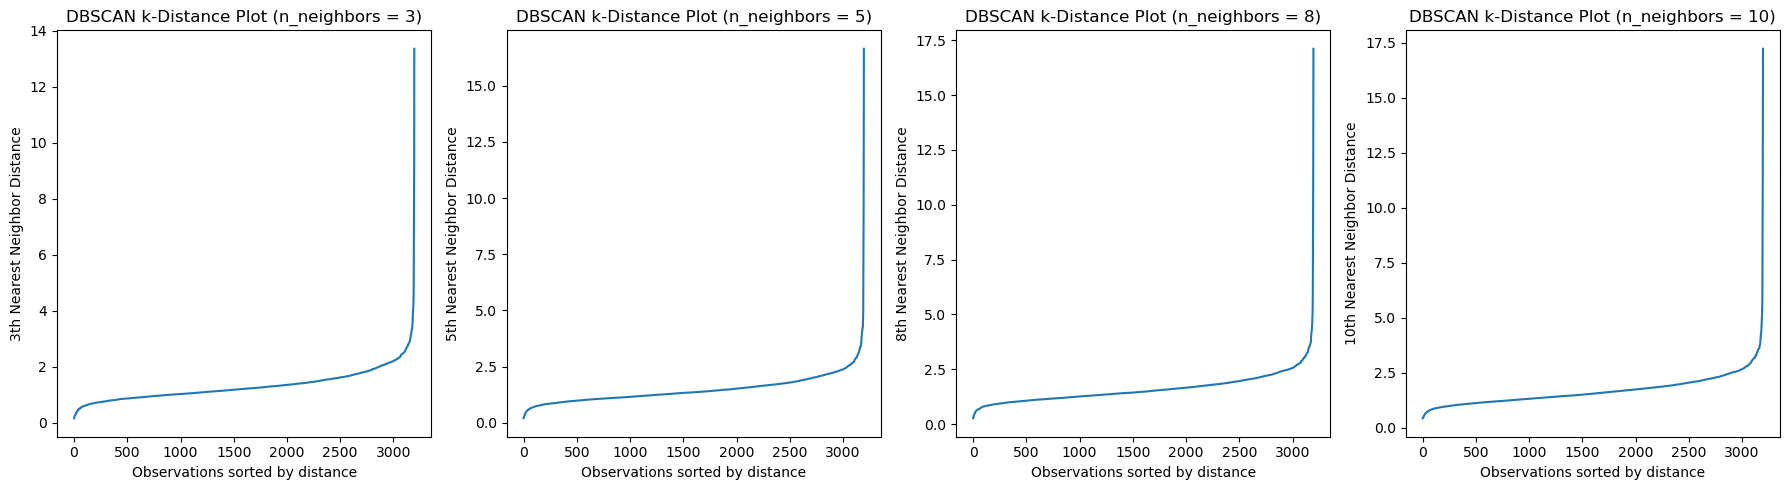

In [26]:
n_neighbors_list = [3,5,8,10]
fig, axes = plt.subplots(1,4, figsize = (18,5))

for i,n in enumerate(n_neighbors_list):
    neighbors = NearestNeighbors(n_neighbors = n)
    neighbors_fit = neighbors.fit(X)

    distances, indicies = neighbors_fit.kneighbors(X)
    kth_distances = np.sort(distances[:, n-1])
    axes[i].plot(kth_distances)
    axes[i].set_xlabel("Observations sorted by distance")
    axes[i].set_ylabel(f"{n}th Nearest Neighbor Distance")
    axes[i].set_title(f"DBSCAN k-Distance Plot (n_neighbors = {n})")

plt.tight_layout()
plt.show()


# DBSCAN Average Silhouette Score

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt



In [21]:
eps_values = [0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
min_samples_values = [3, 5, 8, 10]

dbscan_results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples = min_samples)
        labels = dbscan.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_percent = n_noise /len(labels)

        if n_clusters >= 2:
            non_noise = labels != -1
            score = silhouette_score(X[non_noise], labels[non_noise])
        else:
            score = None
        
        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_percent": noise_percent,
            "silhouette_score": score
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df
        

,eps,min_samples,n_clusters,n_noise,noise_percent,silhouette_score
0,0.8,3,50,2709,0.847357,-0.030017
1,0.8,5,13,2886,0.902721,0.012185
2,0.8,8,6,3015,0.943072,0.238171
3,0.8,10,3,3055,0.955583,0.412475
4,1.0,3,63,2021,0.632155,-0.177453
5,1.0,5,14,2341,0.732249,-0.173547
6,1.0,8,6,2538,0.793869,-0.020101
7,1.0,10,6,2653,0.829840,0.048880
8,1.2,3,57,1352,0.422896,-0.152886
9,1.2,5,22,1650,0.516109,-0.130519


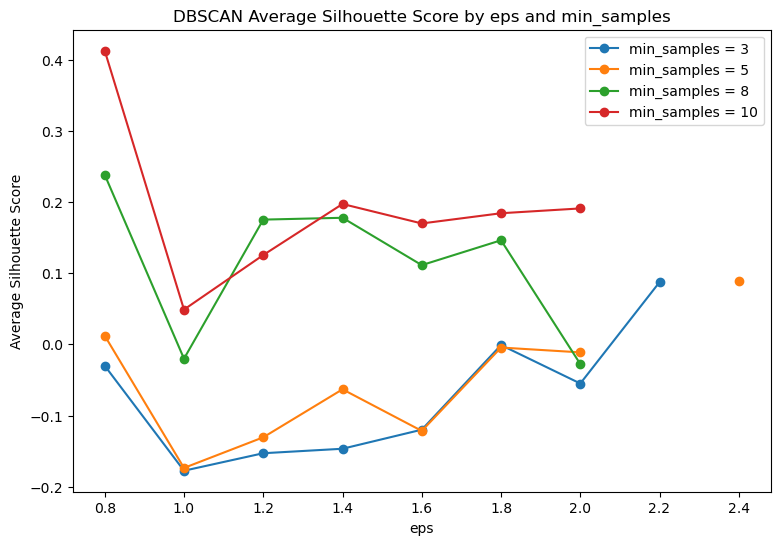

In [22]:
plt.figure(figsize=(9, 6))

for min_samples in min_samples_values:
    temp = dbscan_results_df[
        dbscan_results_df["min_samples"] == min_samples
    ]
    
    plt.plot(
        temp["eps"],
        temp["silhouette_score"],
        marker="o",
        label=f"min_samples = {min_samples}"
    )

plt.xlabel("eps")
plt.ylabel("Average Silhouette Score")
plt.title("DBSCAN Average Silhouette Score by eps and min_samples")
plt.legend()
plt.show()

- ## DBSCAN Parameter Tuning and Clustering Exploration

We created k-distance plots using neighborhood sizes of 3, 5, 8, and 10. In each plot, the distances stayed relatively flat for most observations and then increased sharply near the end. This suggests that reasonable eps values are likely between about 1.8 and 2.6.

As  min_samples increased, the suggested eps values also increased. This is expected because requiring more nearby points usually needs a larger radius.

The DBSCAN results showed a clear tradeoff. Smaller eps values created more clusters, but labeled many observations as noise. Larger eps values reduced the amount of noise, but often merged the data into only one or two large clusters.

The highest silhouette score occurred at a very small eps value, but that setting classified most beers as noise. Because of this, the highest silhouette score was not the most practical clustering result.

More balanced parameter choices appeared around eps = 1.8 to 2.0 with min_samples = 8 or 10. These settings produced a reasonable number of clusters, lower noise percentages, and positive silhouette scores.

Overall, DBSCAN was helpful for identifying dense groups and possible outliers. However, compared with KMeans, DBSCAN did not capture the full structure of the beer dataset as clearly. This may be because many beers vary along continuous flavor profiles rather than forming sharply separated density clusters.

# t-SNE corroboration DBSCAN

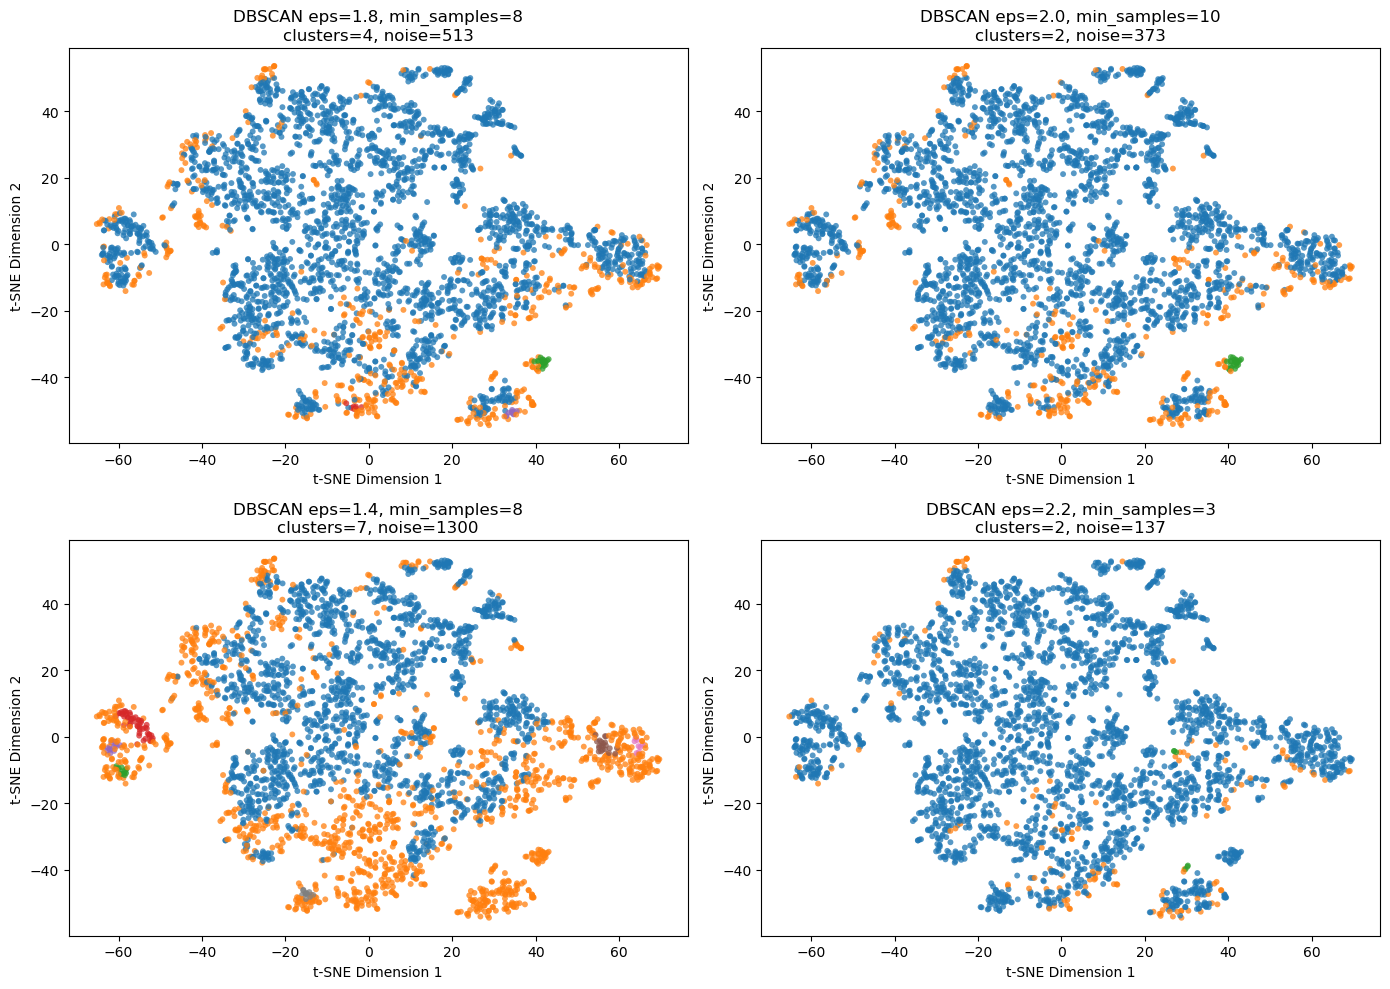

In [27]:
df_tsne  = tsne_results[(30,33)].copy()
param_list = [(1.8, 8),
    (2.0, 10),
    (1.4, 8),
    (2.2, 3)]

fig , axes = plt.subplots(2,2, figsize = (14,10))
for ax, (eps_val, min_val) in zip(axes.flatten(), param_list):
    db = DBSCAN(eps = eps_val, min_samples = min_val)
    labels = db.fit_predict(X)

    plot_df = df_tsne.copy()
    plot_df["cluster"] = labels.astype(str)

    sns.scatterplot(data=plot_df,
        x="tsne_x",
        y="tsne_y",
        hue="cluster",
        palette="tab10",
        s=18,
        alpha=0.75,
        linewidth=0,
        ax=ax,
        legend=False)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)

    ax.set_title(
        f"DBSCAN eps={eps_val}, min_samples={min_val}\n"
        f"clusters={n_clusters}, noise={n_noise}"
    )
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()


## DBSCAN t-SNE Corroboration Interpretation

We compared several DBSCAN parameter settings by color-coding cluster labels on the t-SNE visualization.

For `eps = 1.8` and `min_samples = 8`, DBSCAN identified 4 clusters with a moderate number of noise points. Most observations were placed into one large main cluster, while a few smaller dense regions were separated. This suggests some meaningful local structure, but not strong global separation.

For `eps = 2.0` and `min_samples = 10`, DBSCAN identified 2 clusters with fewer noise points. However, one cluster dominated most of the dataset, meaning this setting may over-merge different beer types into broad groups.

For `eps = 1.4` and `min_samples = 8`, DBSCAN identified 7 clusters with many noise points. This setting captured more local dense pockets, but likely over-fragmented the data and classified too many beers as noise.

For `eps = 2.2` and `min_samples = 3`, DBSCAN identified 2 clusters with relatively low noise. Similar to the previous 2-cluster solution, most beers were grouped together, suggesting limited separation.

Overall, the DBSCAN results did not align with the t-SNE structure as clearly as KMeans. The t-SNE map shows many connected regions and gradual transitions rather than sharply separated dense groups. This suggests the beer dataset may be better represented by broad continuous flavor/style patterns rather than strong density-based clusters.

Among the tested settings, `eps = 1.8` and `min_samples = 8` provided the most balanced DBSCAN result because it detected multiple clusters without classifying an extreme proportion of the data as noise.

# Cluster Sorted Similiarity Matrix

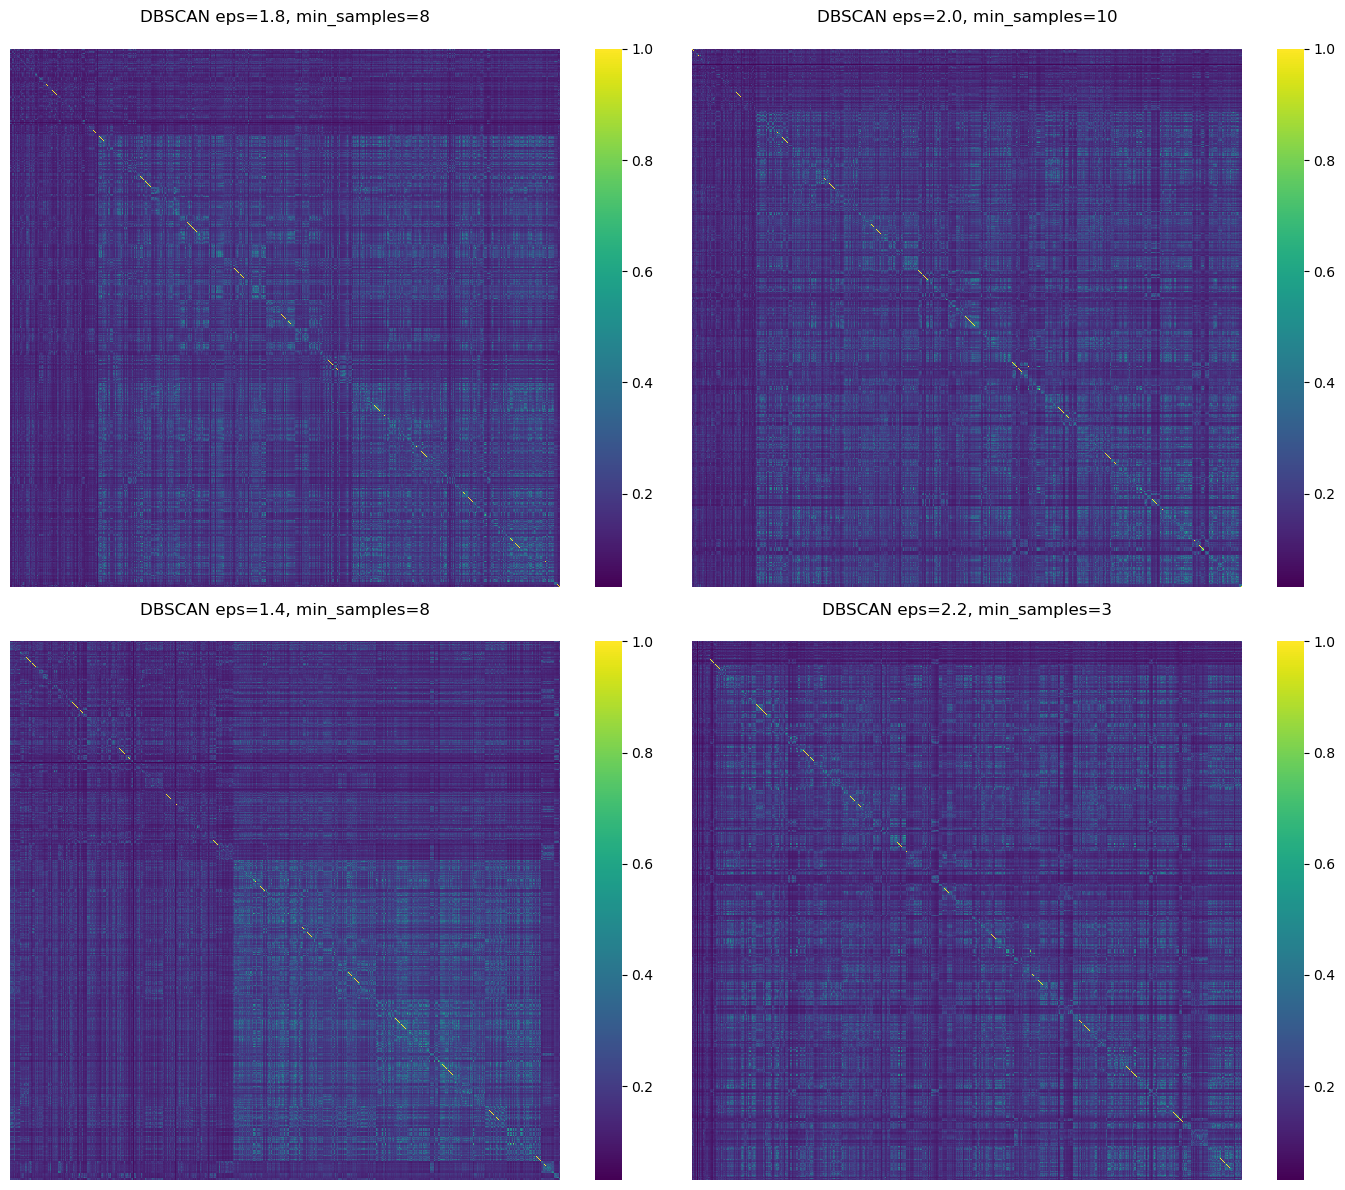

In [28]:
from sklearn.metrics.pairwise import euclidean_distances

dist_mat = euclidean_distances(X)
sim_mat = 1 / (1 + dist_mat)

param_list = [
    (1.8, 8),
    (2.0, 10),
    (1.4, 8),
    (2.2, 3)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (eps_val, min_val) in zip(axes.flatten(), param_list):

    db = DBSCAN(eps=eps_val, min_samples=min_val)
    labels = db.fit_predict(X)

    
    sort_index = np.argsort(labels)

    sim_sorted = sim_mat[sort_index, :][:, sort_index]

    sns.heatmap(
        sim_sorted,
        cmap="viridis",
        xticklabels=False,
        yticklabels=False,
        cbar=True,
        ax=ax
    )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)

    ax.set_title(
        f"DBSCAN eps={eps_val}, min_samples={min_val}\n")
    
plt.tight_layout()
plt.show() 


- The DBSCAN cluster-sorted similarity matrices were less block-structured than the KMeans results, which suggests weaker global cluster separation. This is expected because DBSCAN focuses on local density rather than forcing all observations into partitions.

- Among the tested settings, `eps = 1.8` and `min_samples = 8` showed the most balanced result. Several moderate diagonal blocks were visible, indicating some cohesive dense groups while avoiding excessive merging.

- The setting `eps = 2.0`, `min_samples = 10` appeared over-merged, with weak block structure and limited separation. The setting `eps = 1.4`, `min_samples = 8` created more fragmented clusters and more noise points. The setting `eps = 2.2`, `min_samples = 3` showed little visible structure.

- Overall, the matrices suggest that DBSCAN captured some local dense beer groupings, but the beer dataset does not appear to contain strongly separated density-based clusters.

# Outlier and Noise Handling(DBSCAN)

In [36]:
dbscan_best = DBSCAN(eps = 1.8, min_samples = 8)
dbscan_labels = dbscan_best.fit_predict(X)
df["dbscan_label"] = dbscan_labels

df["dbscan_label"].value_counts().sort_index()
#df.head()
n_noise = (df["dbscan_label"] == -1).sum()
noise_percent = n_noise / len(df)

print("Number of noise points:", n_noise)
print("Noise percentage:", noise_percent)

noise_beers = df[df["dbscan_label"] == -1]

noise_beers.head()


Number of noise points: 513
Noise percentage: 0.16046293400062558


,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,...,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews,dbscan_label
33,Über Alt,Altbier,Rush River Brewing Company,Rush River Brewing Company Über Alt,Notes:Our Alt is a much stronger version of th...,0.774882,0.28848,0.515791,1.487574,0.688816,...,0.463023,-0.140852,2.673203,3.933333,3.866667,4.266667,4.266667,4.166667,15,-1
39,Olde School Barleywine,Barleywine - American,Dogfish Head Brewery,Dogfish Head Brewery Olde School Barleywine,"Notes:Bold, yet smooth! Fermented with dates a...",3.327306,2.93195,2.857498,0.334729,0.341912,...,0.068272,-0.225052,-0.334083,3.902411,3.932262,3.901837,3.931688,3.704363,871,-1
40,Brewer's Reserve Bourbon Barrel Barleywine,Barleywine - American,Central Waters Brewing Company,Central Waters Brewing Company Bourbon Barrel ...,Notes:Aged for 1 year in used bourbon barrels.\t,3.052429,2.93195,2.857498,-0.529905,0.727361,...,-0.589647,0.364350,1.445228,4.369205,4.072848,4.193709,4.307947,4.091060,302,-1
43,Behemoth,Barleywine - American,Three Floyds Brewing Co. & Brewpub,Three Floyds Brewing Co. & Brewpub Behemoth Bl...,"Notes:A huge, sweet barleywine with complex ca...",1.560243,2.93195,2.857498,0.142588,0.958631,...,2.107820,0.238050,0.743528,4.207373,4.123272,4.187788,4.264977,4.059908,434,-1
49,Helldorado,Barleywine - American,Firestone Walker Brewing Co.,Firestone Walker Brewing Co. Helldorado,Notes:Part of the adventure of aging beer in r...,2.463408,2.93195,2.857498,-1.010257,-0.274806,...,0.232751,0.111749,1.470289,4.500000,4.000000,4.000000,4.500000,4.500000,1,-1


In [40]:
noise_beers[
    ["Beer Name (Full)", "Style", "Brewery", "ABV", "Min IBU", "Max IBU",
     "Astringency", "Body", "Alcohol", "Bitter", "Sweet", "Sour",
     "Salty", "Fruits", "Hoppy", "Spices", "Malty"]
].head()

,Beer Name (Full),Style,Brewery,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
33,Rush River Brewing Company Über Alt,Altbier,Rush River Brewing Company,0.774882,0.28848,0.515791,1.487574,0.688816,0.631557,0.412438,2.238570,0.443179,0.460905,0.819732,0.463023,-0.140852,2.673203
39,Dogfish Head Brewery Olde School Barleywine,Barleywine - American,Dogfish Head Brewery,3.327306,2.93195,2.857498,0.334729,0.341912,3.747788,0.761450,3.259695,-0.087924,-0.477041,2.120380,0.068272,-0.225052,-0.334083
40,Central Waters Brewing Company Bourbon Barrel ...,Barleywine - American,Central Waters Brewing Company,3.052429,2.93195,2.857498,-0.529905,0.727361,4.440284,0.140985,2.442795,-0.227688,-0.477041,0.757796,-0.589647,0.364350,1.445228
43,Three Floyds Brewing Co. & Brewpub Behemoth Bl...,Barleywine - American,Three Floyds Brewing Co. & Brewpub,1.560243,2.93195,2.857498,0.142588,0.958631,2.016549,2.079938,1.946821,1.086094,-0.477041,1.934573,2.107820,0.238050,0.743528
49,Firestone Walker Brewing Co. Helldorado,Barleywine - American,Firestone Walker Brewing Co.,2.463408,2.93195,2.857498,-1.010257,-0.274806,2.247380,-0.440701,1.246621,-0.283594,1.867825,0.200375,0.232751,0.111749,1.470289


- Using the selected DBSCAN parameters, `eps = 1.8` and `min_samples = 8`, the model identified 513 beers as noise, which is about 16% of the dataset. This means that these beers did not belong to sufficiently dense regions of the beer profile feature space.

- The beers labeled as noise should not automatically be interpreted as errors. Many of them may represent unusual or niche beer styles with distinctive combinations of alcohol content, bitterness, sweetness, body, or other flavor characteristics. For example, some noise observations include strong or complex beer styles such as American Barleywine, which may naturally differ from more common beer profiles.

- This result is useful for our research goal because DBSCAN allows us to identify beers that do not fit well into the major product-based segments. However, the noise points should be interpreted carefully. They may represent meaningful niche products rather than observations that should be removed from the analysis.

# Best Clustering Evaluation

- Based on the parameter tuning results, the clustering that provided the strongest overall evidence was **DBSCAN with eps = 1.8 and min_samples = 8**.

- First, this clustering appears to capture many of the inherent clusters in the dataset. The t-SNE corroboration plots showed several meaningful dense beer groups while also separating observations that did not clearly belong to any major cluster. This suggests that the model identified natural density-based structure rather than forcing all beers into arbitrary groups.

- Second, this clustering was highly informative because it produced multiple interpretable clusters while still maintaining a manageable number of groups. It revealed that the beer dataset likely contains several major product segments with different flavor and style characteristics rather than only two or three broad categories.

- Third, this clustering was most aligned with our research goals because it handled outliers and niche products appropriately. About 16 percent of observations were labeled as noise, which is reasonable for a large beer dataset containing rare or unusual styles. Instead of forcing these beers into clusters where they do not belong, DBSCAN treated them separately.

- In comparison, KMeans produced cleaner partitions, but it assigns every beer to a cluster even when some beers may be unusual. Therefore, KMeans was useful for segmentation, but DBSCAN better matched the goal of identifying inherent clusters while also handling outliers.

- Overall, **DBSCAN (eps = 1.8, min_samples = 8)** provided the strongest evidence of meaningful clustering structure in this dataset.

# Technique Shortcomings(DBSCAN)

### k-Distance Plot

Yes. The k-distance plot may not suggest one exact DBSCAN parameter choice that perfectly captures the clusters we want. In our beer dataset, the curve increased gradually and did not show one extremely sharp elbow point. This suggests that the data may contain clusters with different densities rather than one common density level. Some beer styles may form dense groups, while others are more spread out. Because of this, choosing one single eps value may not perfectly recover every inherent cluster.

### Average Silhouette Score

Yes. The DBSCAN clustering with the highest average silhouette score may not be the clustering that identifies all inherent clusters. A higher silhouette score can occur when DBSCAN finds only a few dense clusters and labels many observations as noise. While this can improve separation numerically, it may ignore smaller but meaningful beer style groups. Therefore, a solution with a slightly lower silhouette score may actually provide a more complete view of the true clustering structure.

### Cluster-Sorted Similarity Matrices

Yes. A clustering that finds the inherent clusters may still not display perfect block diagonal form. This dataset contains beers with blended characteristics, hybrid styles, and gradual transitions between flavor profiles. Some beers may share similarities with multiple groups at the same time. Because of this overlap, the similarity matrices may show fuzzy boundaries or moderate off-diagonal similarity instead of perfectly clean square blocks. That does not necessarily mean the clustering is poor—it may simply reflect the real structure of the dataset.

# Best Clustering Algorithm Results Presentation

In [41]:
dbscan_final = DBSCAN(eps=1.8, min_samples=8)
dbscan_final_labels = dbscan_final.fit_predict(X)
df["dbscan_final"] = dbscan_final_labels

df["dbscan_final"].value_counts().sort_index()
n_clusters = len(set(dbscan_final_labels)) - (1 if -1 in dbscan_final_labels else 0)
n_noise = sum(dbscan_final_labels == -1)
noise_percent = n_noise / len(dbscan_final_labels)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print("Noise percentage:", noise_percent)

Number of clusters: 4
Number of noise points: 513
Noise percentage: 0.16046293400062558


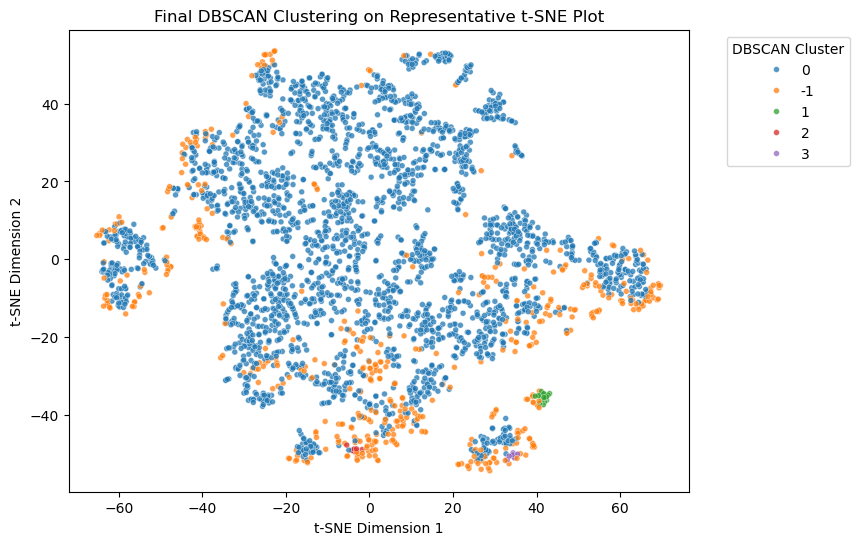

In [42]:
df_tsne_dbscan_final = tsne_results[(30, 33)].copy()
df_tsne_dbscan_final["dbscan_final"] = dbscan_final_labels.astype(str)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_tsne_dbscan_final,
    x="tsne_x",
    y="tsne_y",
    hue="dbscan_final",
    palette="tab10",
    s=18,
    alpha=0.75
)

plt.title("Final DBSCAN Clustering on Representative t-SNE Plot")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="DBSCAN Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- The final DBSCAN result produced 4 clusters with 513 noise points (16.0% of the dataset).

- Most observations were assigned to one large main cluster, suggesting that many beers share connected and gradually changing flavor characteristics rather than forming sharply separated groups.

- Several smaller dense clusters were also detected, likely representing niche beer styles with highly distinct profiles.

- Noise points were mostly located around cluster boundaries or isolated regions, indicating beers that do not strongly belong to any dense group.

- Compared with KMeans, DBSCAN suggests that the beer market may consist of one broad connected product space with several specialized subgroups rather than many completely separate categories.

# Review Variables Analysis(DBSCAN)

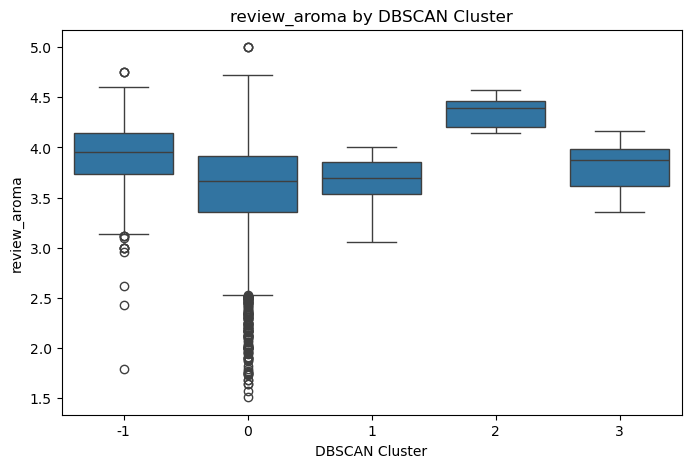

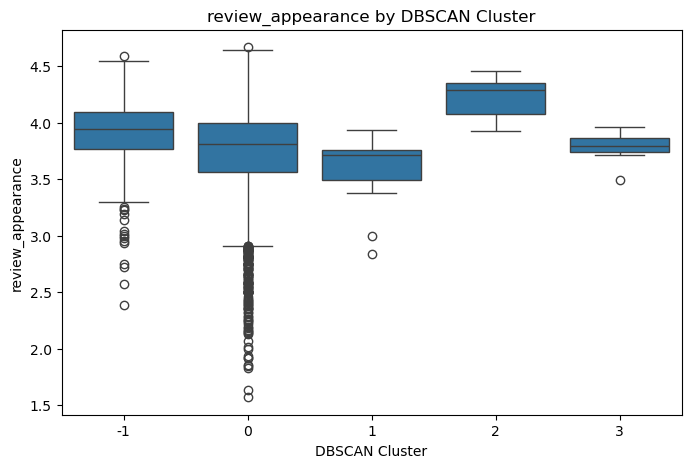

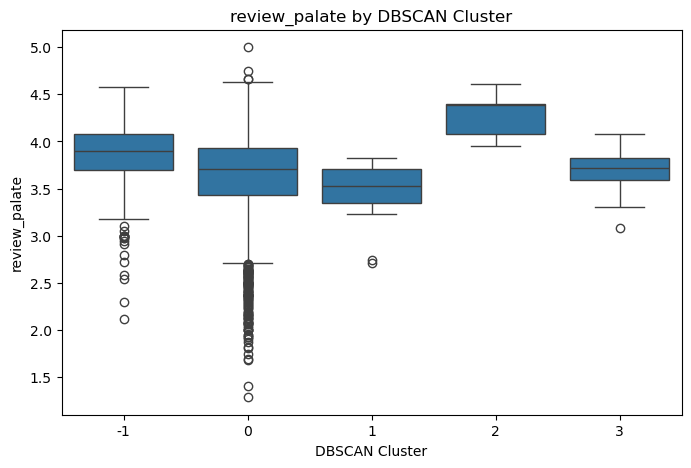

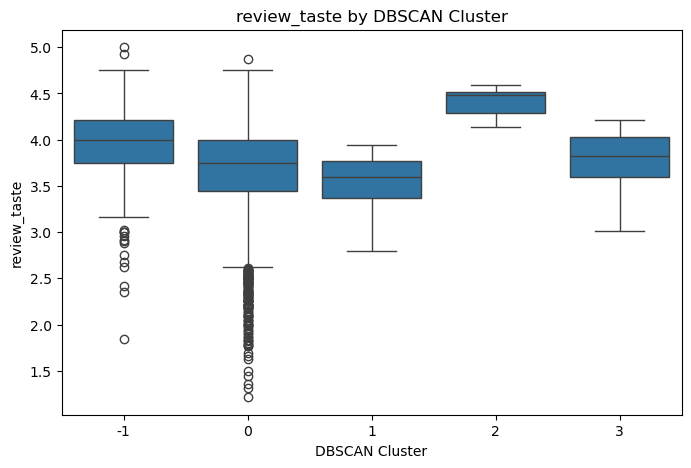

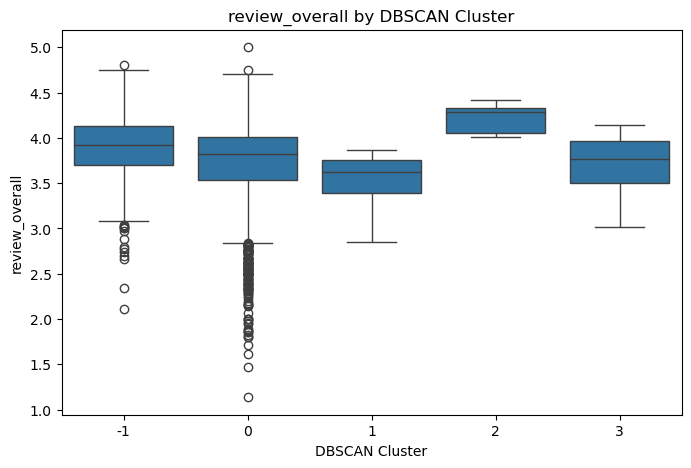

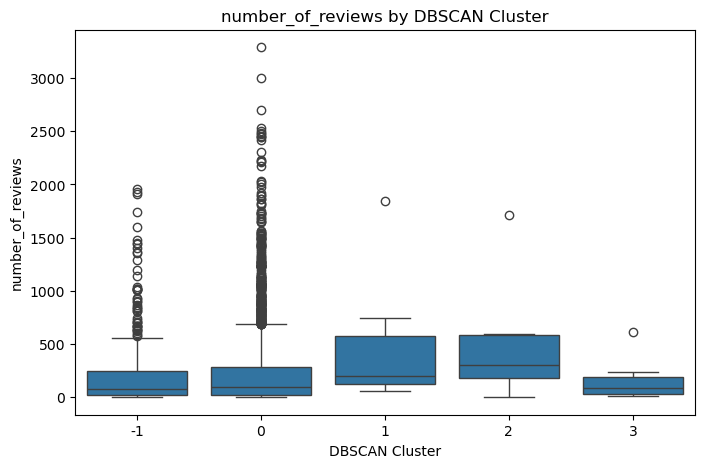

In [44]:
review_cols = [
    "review_aroma",
    "review_appearance",
    "review_palate",
    "review_taste",
    "review_overall",
    "number_of_reviews"
]

for col in review_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.boxplot(
        data=df,
        x="dbscan_final",
        y=col
    )
    
    plt.title(f"{col} by DBSCAN Cluster")
    plt.xlabel("DBSCAN Cluster")
    plt.ylabel(col)
    
    plt.show()


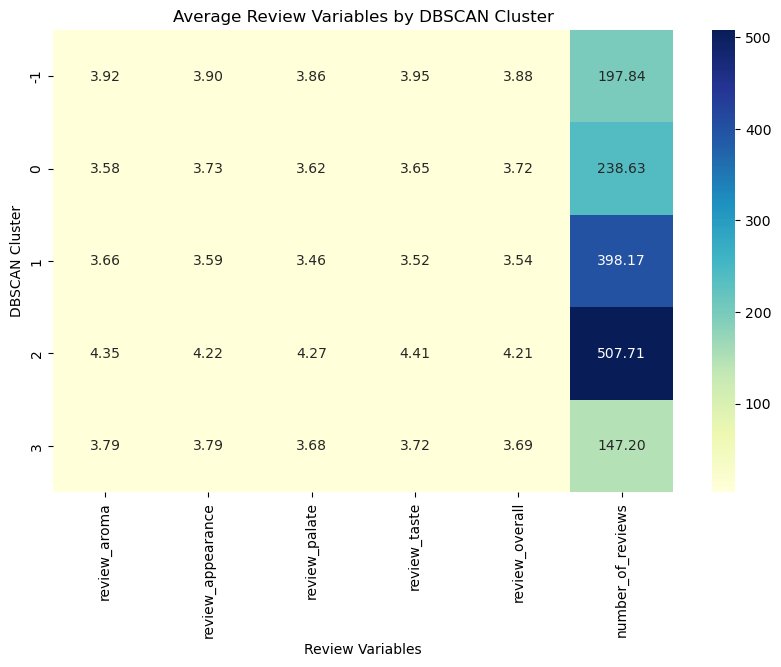

In [45]:
review_cols = [
    "review_aroma",
    "review_appearance",
    "review_palate",
    "review_taste",
    "review_overall",
    "number_of_reviews"
]

cluster_review_means = df.groupby("dbscan_final")[review_cols].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_review_means,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average Review Variables by DBSCAN Cluster")
plt.xlabel("Review Variables")
plt.ylabel("DBSCAN Cluster")

plt.show()

- The DBSCAN clusters showed clear differences in consumer review behavior, suggesting that the density-based product clusters are meaningful from a customer perspective.

- Cluster 2 had the highest ratings across nearly all review variables, including aroma, palate, taste, and overall score. It also had the highest average number of reviews. This suggests that Cluster 2 represents a premium and popular beer segment.

- Cluster 1 had the lowest ratings across most review categories, indicating a less preferred beer group.

- Cluster 0 is cluster with moderate ratings and wide variation, suggesting a broad mix of average-quality beers.

- Cluster 3 had moderate ratings but fewer reviews, which may represent a smaller niche segment.

- Interestingly, the noise observations still had relatively solid review scores. This suggests that beers labeled as noise by DBSCAN are not poor products, but rather unique beers that do not fit into dense mainstream clusters.

- Overall, the review analysis supports that the DBSCAN clustering captured meaningful product groups with different levels of customer satisfaction.